In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string

nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /home/shadow/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [143]:
df = pd.read_csv('./spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [144]:
df.shape

(5572, 5)

# 1. Data Cleaning

In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [146]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [147]:
df.rename(columns={'v1':'target', 'v2':'text'},inplace=True)

In [148]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [149]:
df['target'] = encoder.fit_transform(df['target'])

In [150]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [151]:
# missing values

df.isnull().sum()

target    0
text      0
dtype: int64

In [152]:
df = df.drop_duplicates(keep='first')

In [153]:
df.shape

(5169, 2)

In [154]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

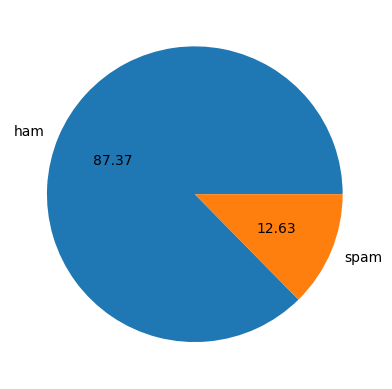

In [155]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [156]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/shadow/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [157]:
df['num_char'] = df['text'].apply(len)

In [158]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [159]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [160]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [161]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [162]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [163]:
df[['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [164]:
# For HAM messages
df[df['target'] == 0][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [165]:
# For SPAM messages
df[df['target'] == 1][['num_char', 'num_words', 'num_sentences']].describe()

,num_char,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


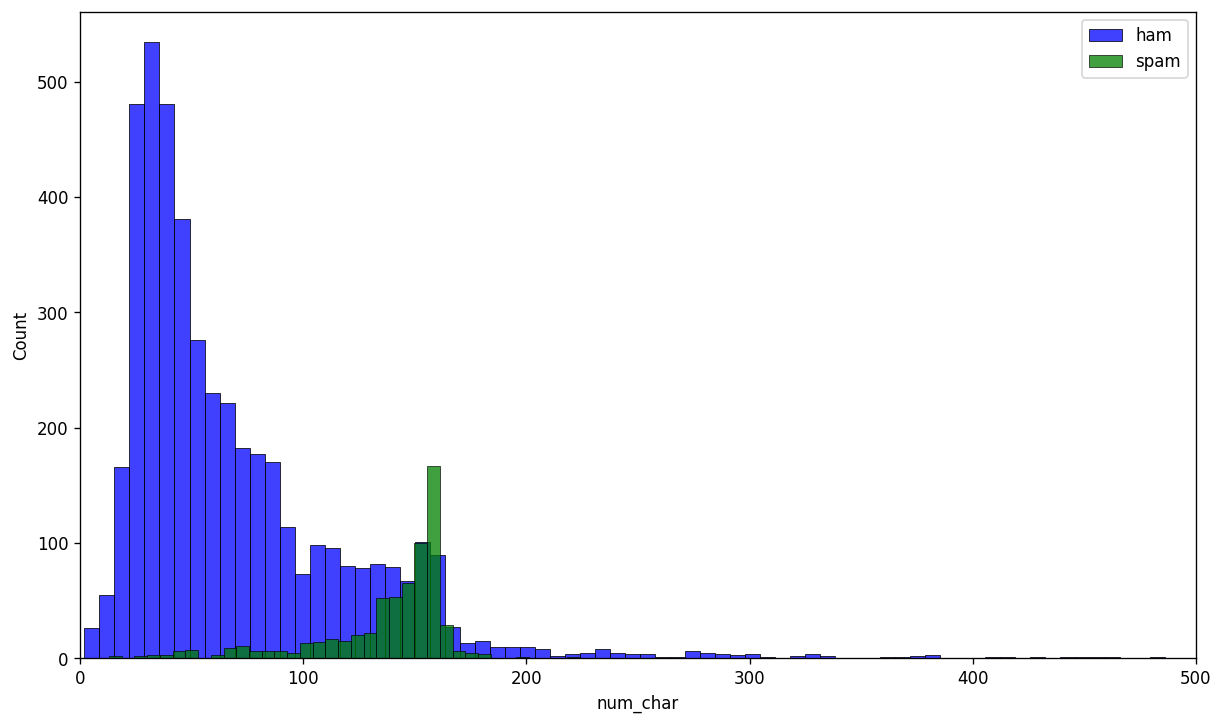

In [166]:
plt.figure(figsize=(12,7), dpi=120)

sns.histplot(data=df[df['target'] == 0], x='num_char', color='blue', label='ham')
sns.histplot(data=df[df['target'] == 1], x='num_char', color='green', label='spam')

plt.xlim(0, 500)

plt.legend()
plt.show()

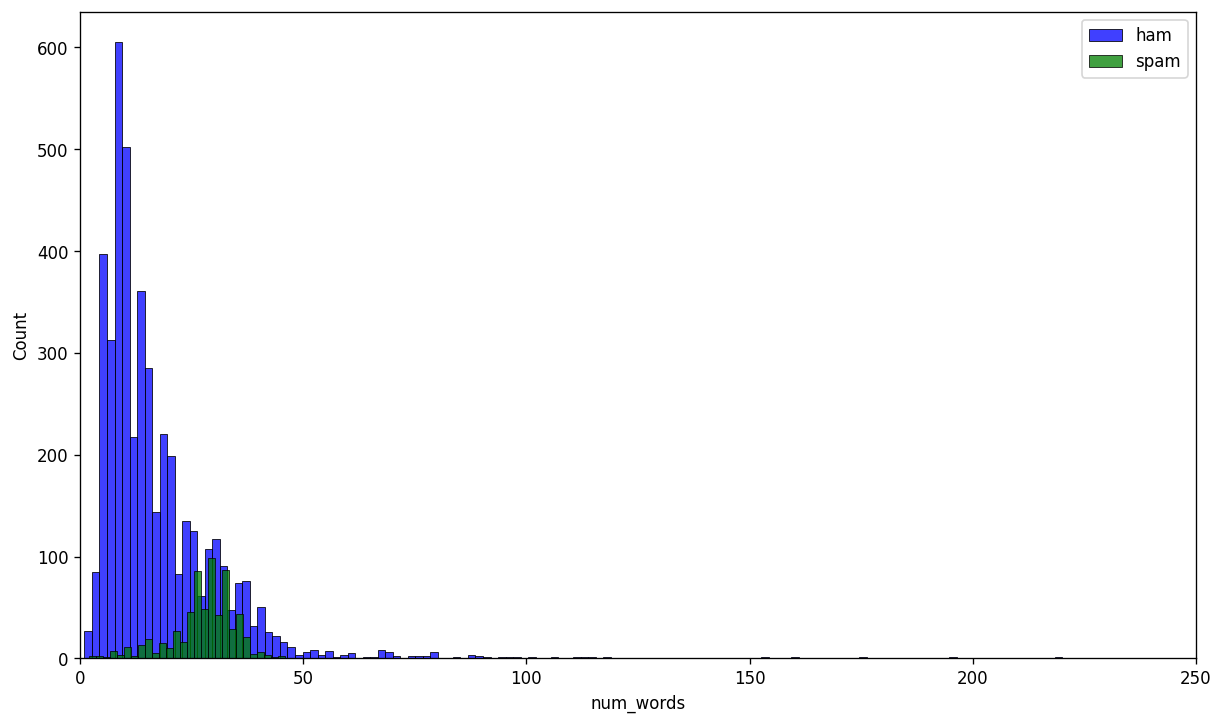

In [167]:
plt.figure(figsize=(12,7), dpi=120)

sns.histplot(data=df[df['target'] == 0], x='num_words', color='blue', label='ham')
sns.histplot(data=df[df['target'] == 1], x='num_words', color='green', label='spam')

plt.xlim(0, 250)

plt.legend()
plt.show()

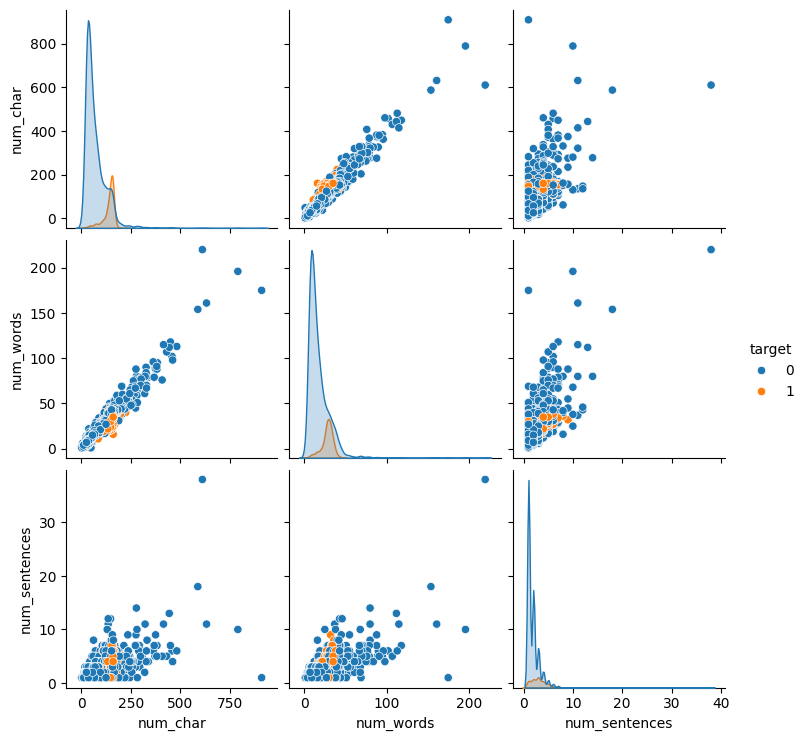

In [168]:
sns.pairplot(df, hue='target')

<Axes: >

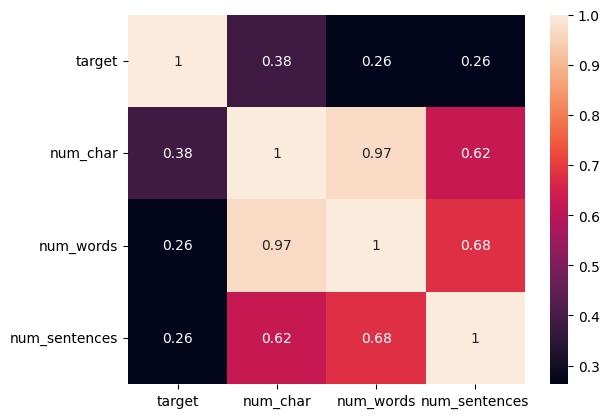

In [169]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Preprocessing

In [170]:
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [171]:
transform_text(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [172]:
df['transform_text'] = df['text'].apply(transform_text)

KeyboardInterrupt: 

In [ ]:
df.head()

,target,text,num_char,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep=" "))

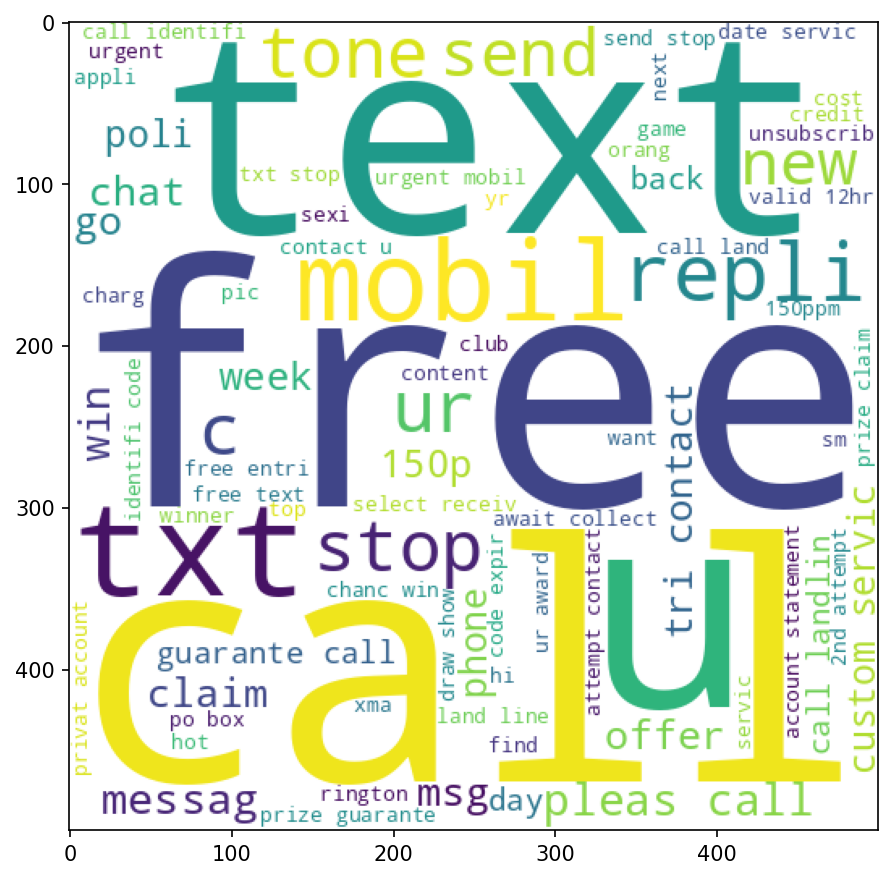

In [ ]:
plt.figure(figsize=(12,7), dpi=150)
plt.imshow(spam_wc)

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep=" "))

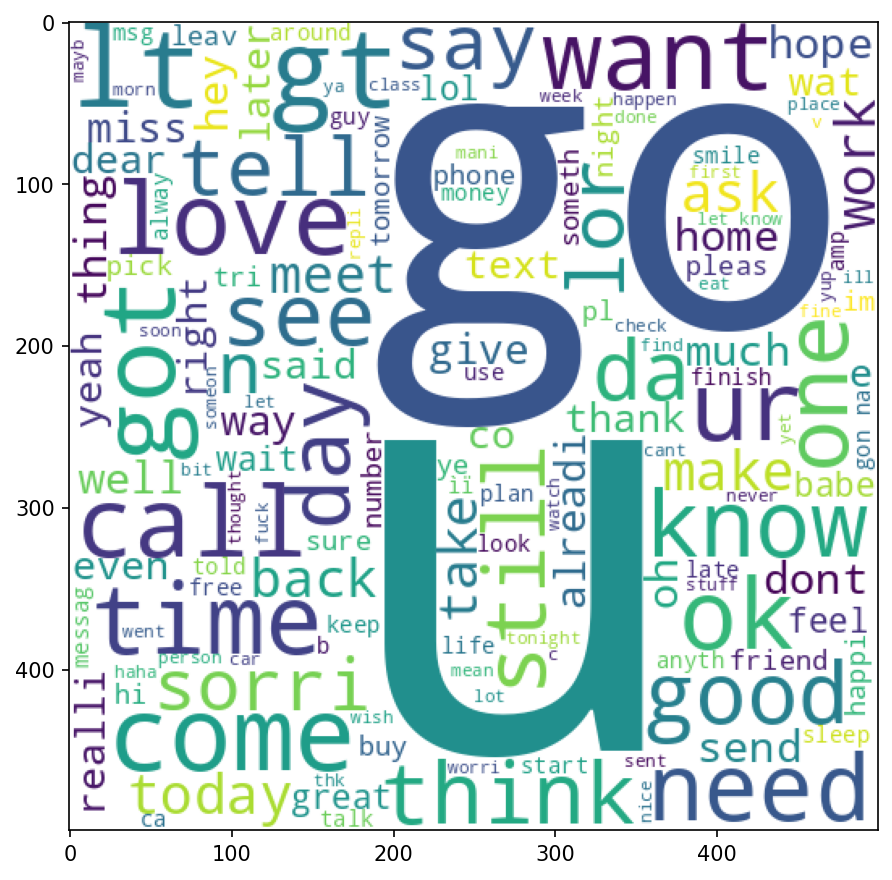

In [ ]:
plt.figure(figsize=(12,7), dpi=150)
plt.imshow(ham_wc)

In [ ]:
spam_corpas = []

for msg in df[df['target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpas.append(word)

/tmp/ipykernel_1387063/2796185011.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = pd.DataFrame(Counter(spam_corpas).most_common(30)),x=pd.DataFrame(Counter(spam_corpas).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpas).most_common(30))[1], palette='Dark2');


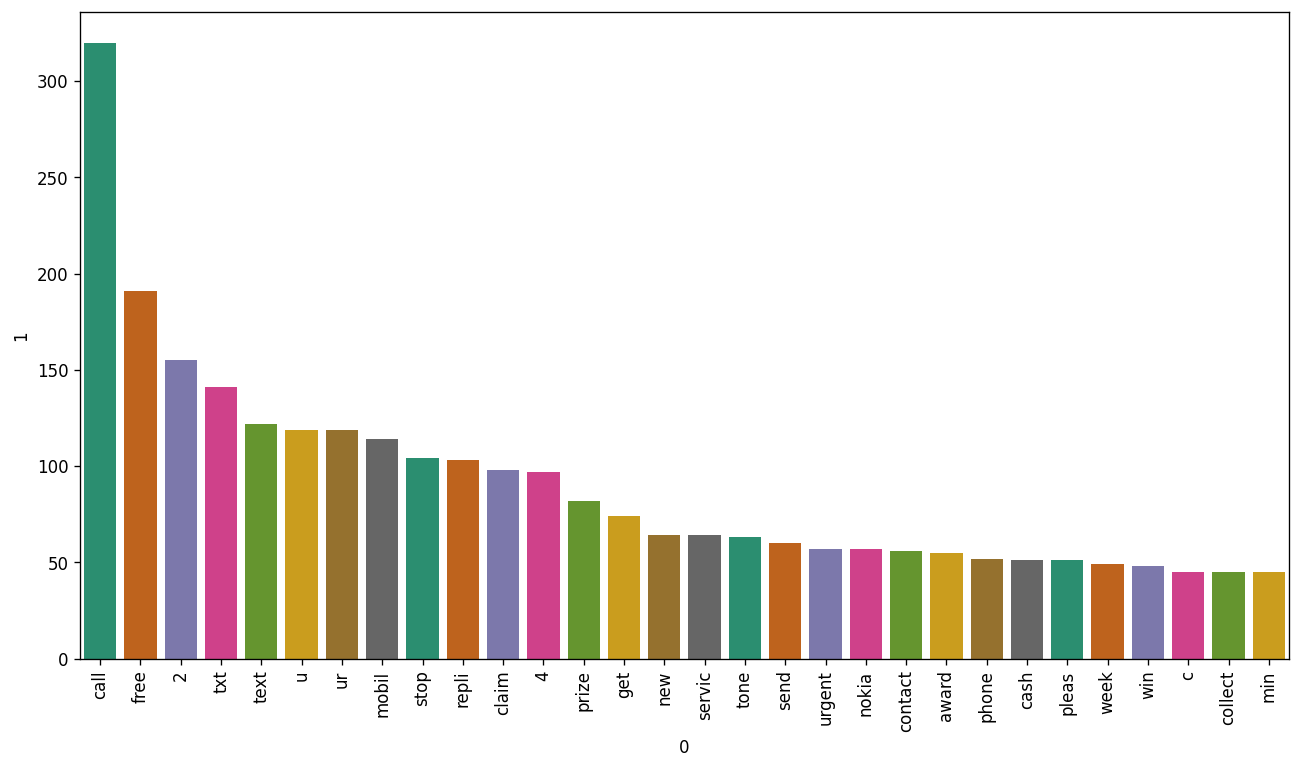

In [ ]:
from collections import Counter

plt.figure(figsize=(13,7), dpi=120);
sns.barplot(data = pd.DataFrame(Counter(spam_corpas).most_common(30)),x=pd.DataFrame(Counter(spam_corpas).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpas).most_common(30))[1], palette='Dark2');
plt.xticks(rotation=90);

In [ ]:
ham_corpas = []

for msg in df[df['target'] == 0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpas.append(word)

/tmp/ipykernel_1387063/3616129071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = pd.DataFrame(Counter(ham_corpas).most_common(30)),x=pd.DataFrame(Counter(ham_corpas).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpas).most_common(30))[1], palette='Dark2');


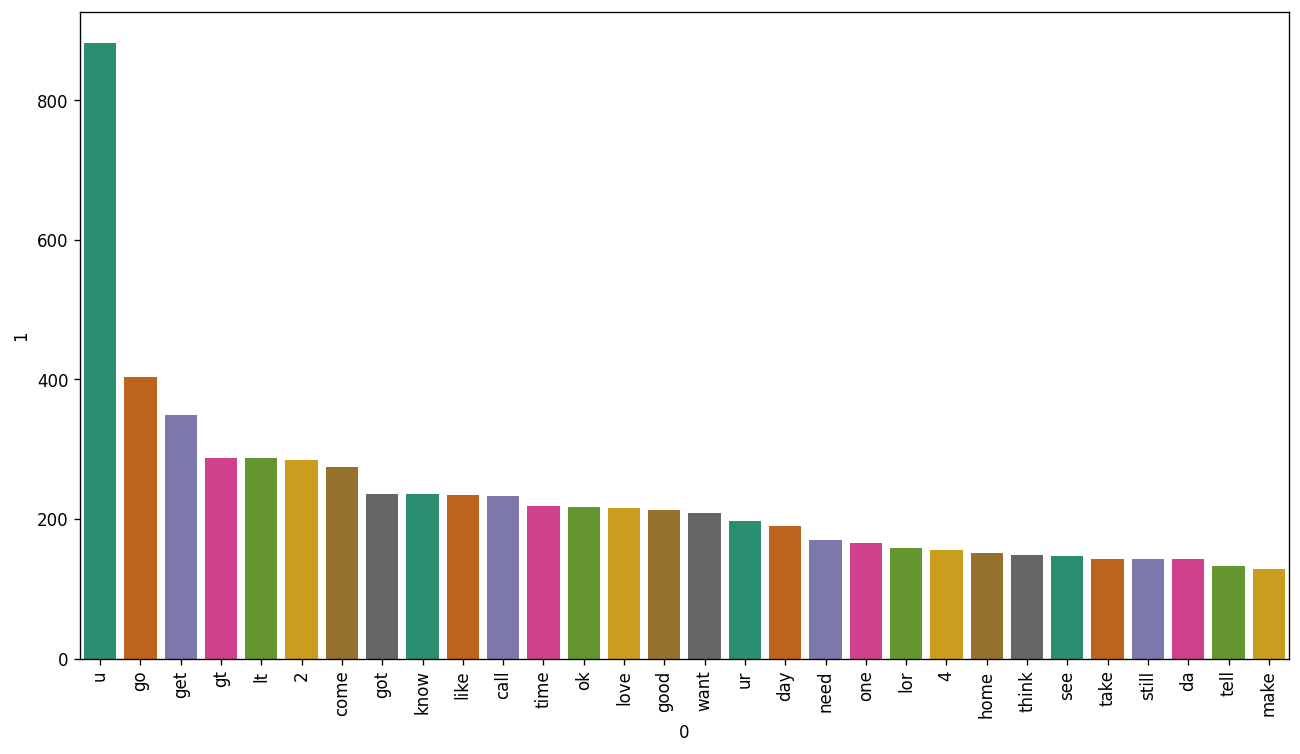

In [ ]:
from collections import Counter

plt.figure(figsize=(13,7), dpi=120);
sns.barplot(data = pd.DataFrame(Counter(ham_corpas).most_common(30)),x=pd.DataFrame(Counter(ham_corpas).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpas).most_common(30))[1], palette='Dark2');
plt.xticks(rotation=90);

# Model Bulding

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [ ]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [ ]:
X.shape

(5169, 3000)

In [ ]:
y = df['target'].values

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, precision_score

In [ ]:
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()

0.874274661508704
0.5181818181818182


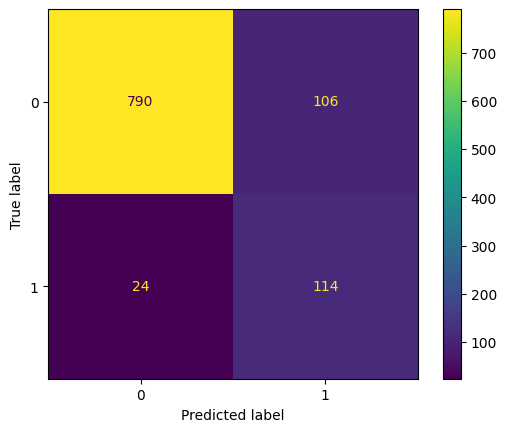

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(precision_score(y_test, y_pred1))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)

0.9709864603481625
1.0


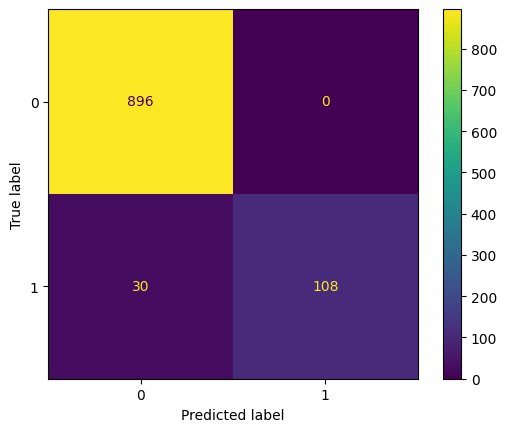

In [ ]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(precision_score(y_test, y_pred2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)

0.9835589941972921
0.991869918699187


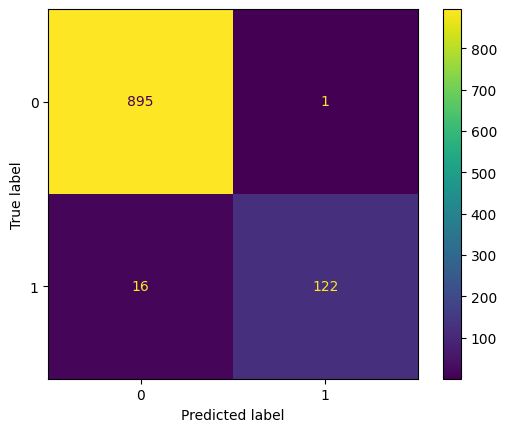

In [ ]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(precision_score(y_test, y_pred3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred3)

# Model Traning 2

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF':rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [ ]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_preds = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    
    return accuracy, precision

In [ ]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9758220502901354, 0.9747899159663865)

In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/shadow/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
performance_df = pd.DataFrame({'Algo':clfs.keys(), 'Accuracy':accuracy_scores, 'Precision': precision_scores}).sort_values('Precision', ascending=False)

performance_df

,Algo,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algo")

<Figure size 960x720 with 0 Axes>

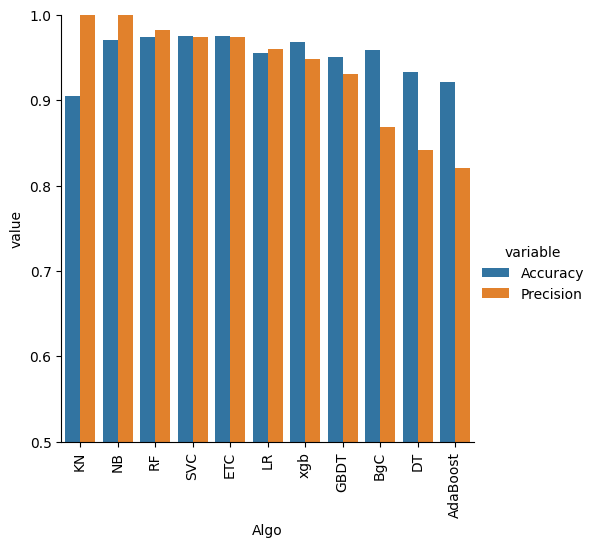

In [ ]:
plt.figure(dpi=150)
sns.catplot(x = 'Algo', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
temp_df = pd.DataFrame({'Algo':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [ ]:
new_df = performance_df.merge(temp_df,on='Algo')

In [ ]:
new_df.head()

,Algo,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576


In [173]:
# # Voting Classifier

# svc = SVC(kernel='sigmoid', gamma=0.1, probability=True)
# final_mnb = MultinomialNB()
# etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

# from sklearn.ensemble import VotingClassifier

# voting = VotingClassifier(estimators=[('svc',svc), ('mnb', final_mnb), ('etc', etc)], voting='soft')

# voting.fit(X_train,y_train)

# y_pred = voting.predict(X_test)

# from sklearn.utils.validation import check_is_fitted
# check_is_fitted(final_mnb)
# print('Model is fitted')

In [174]:
# Voting Classifier

from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.validation import check_is_fitted
import pickle

print("X_train type:", type(X_train))
print("X_train shape:", X_train.shape)
print("y_train type:", type(y_train))
print("y_train shape:", y_train.shape)

final_mnb = MultinomialNB()
print("Before fit — has classes_ attr?", hasattr(final_mnb, 'classes_'))

try:
    final_mnb.fit(X_train, y_train)
    print("fit() completed without raising an exception")
except Exception as e:
    print("fit() RAISED an exception:", type(e).__name__, e)

print("After fit — has classes_ attr?", hasattr(final_mnb, 'classes_'))
print("id of final_mnb:", id(final_mnb))

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('svc',svc), ('mnb', final_mnb), ('etc', etc)], voting='soft')

voting.fit(X_train,y_train)

y_pred = voting.predict(X_test)

from sklearn.utils.validation import check_is_fitted
check_is_fitted(final_mnb)
print('Model is fitted')

check_is_fitted(final_mnb)
print("check_is_fitted passed ✅")

X_train type: <class 'numpy.ndarray'>
X_train shape: (4135, 3000)
y_train type: <class 'numpy.ndarray'>
y_train shape: (4135,)
Before fit — has classes_ attr? False
fit() completed without raising an exception
After fit — has classes_ attr? True
id of final_mnb: 139997212449936
Model is fitted
check_is_fitted passed ✅


In [175]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9758220502901354
Precision 0.9747899159663865


In [176]:
# Stacking Classifier

estimators=[('svm', svc), ('nb', final_mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [177]:
from sklearn.ensemble import StackingClassifier

In [178]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [179]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 0.946969696969697


In [180]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(final_mnb,open('model.pkl','wb'))